# Assignment 3: Supervised vs Unsupervised Learning on Titanic Dataset

**Name:**  
**Guardian Name:**  
**Email ID:**  
**Contact Number:**  
**Enrollment No.:** 473611

## Question

Titanic Learning Lab: Supervised vs Unsupervised.

**Goal:** Compare Logistic Regression, which is supervised learning, with K-Means, which is unsupervised learning.

## Answer

Logistic Regression is supervised because it learns from features and the known `Survived` target. K-Means is unsupervised because it does not use the survival answer. It groups passengers by similarity using features such as `Age`, `Fare`, and `Pclass`.

In [1]:
from pathlib import Path

import pandas as pd


def find_titanic_train_csv():
    candidates = []
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidates.extend([
            base / 'kaggle' / 'train.csv',
            base / 'data' / 'train.csv',
            base / 'train.csv',
        ])
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not find kaggle/train.csv. Run this notebook from the project root or upload train.csv.')

train_path = find_titanic_train_csv()
titanic = pd.read_csv(train_path)
print(f'Loaded: {train_path}')
print(titanic.shape)
titanic.head()

Loaded: /Users/sid_mac/Documents/GitHub/titanic-data-to-discovery/kaggle/train.csv
(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Part 1: Supervised Learning - Logistic Regression.
X = titanic[['Age', 'Pclass', 'Sex']].copy()
y = titanic['Survived'].copy()

X['Age'] = X['Age'].fillna(X['Age'].mean())
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)

print('Supervised Learning: Logistic Regression')
print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('Classification Report:')
print(classification_report(y_test, y_pred))

Supervised Learning: Logistic Regression
Accuracy: 0.7877
Confusion Matrix:
[[94 16]
 [22 47]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       110
           1       0.75      0.68      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



Unsupervised Learning: K-Means Clustering
Cluster Centers:


,Age,Fare,Pclass
0,28.64,15.45,2.55
1,31.02,279.31,1.00
2,34.96,83.39,1.25


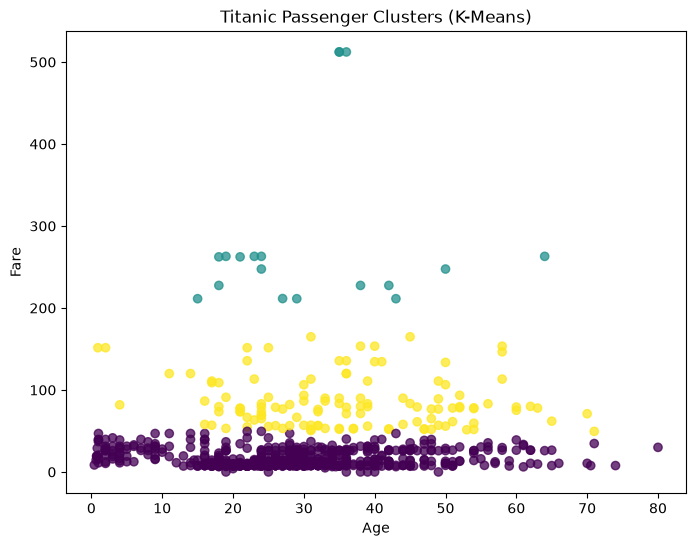

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Part 2: Unsupervised Learning - K-Means Clustering.
X_cluster = titanic[['Age', 'Fare', 'Pclass']].copy()
X_cluster = X_cluster.fillna(X_cluster.mean(numeric_only=True))

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
titanic_with_clusters = titanic.copy()
titanic_with_clusters['Cluster'] = kmeans.fit_predict(X_cluster)

centers = pd.DataFrame(kmeans.cluster_centers_, columns=['Age', 'Fare', 'Pclass'])
print('Unsupervised Learning: K-Means Clustering')
print('Cluster Centers:')
display(centers.round(2))

plt.figure(figsize=(8, 6))
plt.scatter(
    titanic_with_clusters['Age'],
    titanic_with_clusters['Fare'],
    c=titanic_with_clusters['Cluster'],
    cmap='viridis',
    alpha=0.75,
)
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Titanic Passenger Clusters (K-Means)')
plt.show()

## Learning

Supervised learning uses known answers to make predictions. Unsupervised learning finds patterns without a target answer. In this assignment, Logistic Regression predicts survival, while K-Means discovers passenger groups.